In [311]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

from src.config_presets.tools.get_config import get_config


config = get_config('Daniel/VM_uncertainty')

endpoint_list = config['columns']['labels']

endpoint_list

['Dysphagia_M06']

In [323]:
UQ_method_folder_names_dict = {"MC Dropout" : "DATA MC Dropout", 
                               #"TTA" : "DATA TTA",
                               #"Deep Ensemble" : "DATA Deep Ensemble"
                               }
endpoint_folders_dict = {'Xerostomia_M06' : 'Xerostomia_1',
                         "Dysphagia_M06" : "Dysphagia_1",
                         "OS_2year_censored" : "OS_1_m3",
                         "LRC_2year_censored" : "LRC_1"}

ALL_DFS_DICT = {}

for endpoint_name, endpoint_folder_name in endpoint_folders_dict.items():
    ALL_DFS_DICT[endpoint_name] = {}

    for UQ_method_name, UQ_method_folder in UQ_method_folder_names_dict.items():
        ALL_DFS_DICT[endpoint_name][UQ_method_name] = {}

        # list all N_patients folders
        root_dir = os.path.join("/home/macraedc/rt_pred_results/", UQ_method_folder, endpoint_folder_name)
        n_patients_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]

        for n_patients_folder in n_patients_folders:
            n_patients = n_patients_folder.split("_")[-1]
            
            if UQ_method_name == "Deep Ensemble":
                all_preds_csv_dir = os.path.join(root_dir, n_patients_folder, "all_predictions.csv")
            else:
                all_preds_csv_dir = os.path.join(root_dir, n_patients_folder, "model_1", "all_predictions.csv")
            all_preds_df = pd.read_csv(all_preds_csv_dir, sep=';')

            ALL_DFS_DICT[endpoint_name][UQ_method_name][n_patients] = all_preds_df


def reorder_nested_dict(original_dict):
    reordered = {}
    for a_key, b_dict in original_dict.items():
        for b_key, c_dict in b_dict.items():
            for c_key, value in c_dict.items():
                # Create the new structure: A -> C -> B
                reordered.setdefault(a_key, {}).setdefault(c_key, {})[b_key] = value
    return reordered

#ALL_DFS_DICT = reorder_nested_dict(ALL_DFS_DICT)
# Example usage:
# original_dict = {'A1': {'B1': {'C1': 1, 'C2': 2}, 'B2': {'C1': 3}}}
# new_dict = reorder_nested_dict(original_dict)

In [324]:
ALL_DFS_DICT['Xerostomia_M06'].keys()

dict_keys(['MC Dropout'])

In [304]:
n_patients

'200'

In [305]:
root_dir = "/home/macraedc/rt_pred_results/DATA Deep Ensemble/Xerostomia_1"

folders = os.listdir(root_dir)  

In [306]:
ALL_DFS_DICT = {"Xerostomia_M06" : dict()}
for folder in folders:
    n_patients = folder.split("_")[-1]
    #all_preds_csv_dir = os.path.join(root_dir, folder, 'model_1', "all_predictions.csv")
    all_preds_csv_dir = os.path.join(root_dir, folder, "all_predictions.csv")
    all_preds_df = pd.read_csv(all_preds_csv_dir, sep=';')
    ALL_DFS_DICT["Xerostomia_M06"][n_patients] = all_preds_df


In [307]:
ALL_DFS_DICT['Xerostomia_M06'].keys()

dict_keys(['100', '200', '300', '400', '500', '600', '700', '800'])

In [325]:
%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance

def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    #label_columns = [x + '_true' for x in endpoint_list]
    endpoint_pred_columns = [col for col in df.columns if 'pred' in col]

    all_endpoint_preds = df[endpoint_pred_columns]
    #all_endpoint_preds = (all_endpoint_preds - all_endpoint_preds.min().min()) / (all_endpoint_preds.max().max() - all_endpoint_preds.min().min())
    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)

    # if endpoint == "OS":
    #     plt.hist(mean_endpoint_preds, bins=50, alpha=0.3)

    df_UQ_results['Mean Prediction'] = mean_endpoint_preds

    
    df_UQ_results['True Labels'] = df[endpoint + '_true']
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)

    return df_UQ_results


UQ_RESULTS_DICT = {}


#  ALL_DFS_DICT[endpoint_folder][UQ_method_folder][n_patients]

for endpoint, dfs in ALL_DFS_DICT.items():
    UQ_RESULTS_DICT[endpoint] = {}

    for method, method_dfs in dfs.items():
        UQ_RESULTS_DICT[endpoint][method] = {}

        for amount, df_all_preds in method_dfs.items():
            # label_columns = [x + '_true' for x in endpoint_list]
            # pred_columns = [col for col in dfs.columns if 'pred' in col]

            df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)
            UQ_RESULTS_DICT[endpoint][method][amount] = df_UQ_results


#UQ_methods_list = list(ALL_DFS_DICT["Dysphagia_M06"].keys()) 
#UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [326]:
UQ_methods_list = list(UQ_RESULTS_DICT["Xerostomia_M06"].keys()) 
UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]

ENDPOINT_TYPES = {
    "Xerostomia_M06": "Binary",
    "Dysphagia_M06": "Binary",
    "OS_2year_censored": "Binary",
    "LRC_2year_censored": "Binary"
    #"OS_2year_no_clinical": "Binary"
    
}

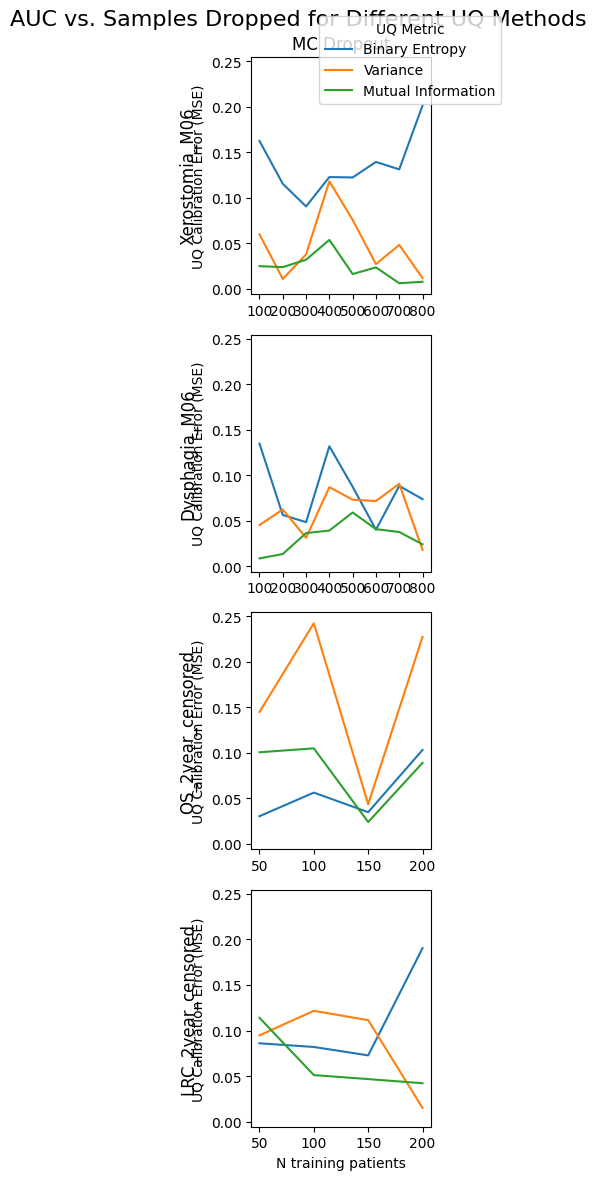

In [327]:
from src.uncertainty.visualisation.plotting_UQ import plot_nested_UQ


fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="calibration_error_dataset_size", row_key="endpoint", col_key="method")

plt.show()

# 
# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="sparsification", row_key="endpoint", col_key="method")

# plt.show()


In [273]:
UQ_RESULTS_DICT['Xerostomia_M06'].keys()

dict_keys(['MC Dropout', 'TTA', 'Deep Ensemble'])

In [241]:
UQ_methods_list

['100', '200', '300', '400', '500', '600', '700', '800']

In [242]:
UQ_metrics_list

['Binary Entropy', 'Variance', 'Mutual Information']

In [232]:
from src.uncertainty.metrics.make_table import make_nested_UQ_table
from src.evaluation.metrics.calibration import ECE

metric_func  = ECE

df_metrics = make_nested_UQ_table(
    config,
    UQ_RESULTS_DICT,
    ENDPOINT_TYPES,
    UQ_methods_list,
    UQ_metrics_list,
    metric_func,
    N_bins = 5
)

df_metrics

TypeError: 'NoneType' object is not subscriptable

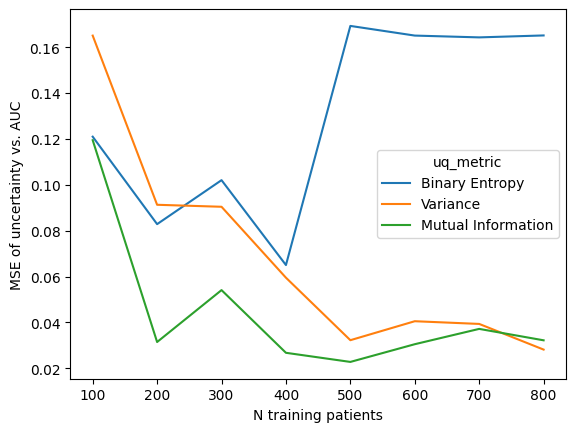

In [173]:
df_metrics[df_metrics['uq_metric'] == 'Variance']

import matplotlib.pyplot as plt

for uq_metric in df_metrics['uq_metric'].unique():
    subset = df_metrics[df_metrics['uq_metric'] == uq_metric]
    plt.plot(subset['method'], subset['metric_value'], label=uq_metric)


plt.xlabel('N training patients')
plt.ylabel('MSE of uncertainty vs. AUC')
plt.legend(title='uq_metric')
plt.show()

In [ ]:
def reorder_nested_dict(original_dict):
    reordered = {}
    for a_key, b_dict in original_dict.items():
        for b_key, c_dict in b_dict.items():
            for c_key, value in c_dict.items():
                # Create the new structure: A -> C -> B
                reordered.setdefault(a_key, {}).setdefault(c_key, {})[b_key] = value
    return reordered

# Example usage:
# original_dict = {'A1': {'B1': {'C1': 1, 'C2': 2}, 'B2': {'C1': 3}}}
# new_dict = reorder_nested_dict(original_dict)

In [ ]:
def plot_nested_dict_subfigures(nested_dict, swap_axes=False):
    A_keys = list(nested_dict.keys())
    B_keys = list(next(iter(nested_dict.values())).keys())
    n_A = len(A_keys)
    n_B = len(B_keys)

    # Set rows/cols based on swap_axes
    n_rows, n_cols = (n_B, n_A) if swap_axes else (n_A, n_B)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

    for i, a_key in enumerate(A_keys):
        for j, b_key in enumerate(B_keys):
            # Swap axes if needed
            row_idx, col_idx = (j, i) if swap_axes else (i, j)
            ax = axes[row_idx, col_idx] if n_rows > 1 and n_cols > 1 else axes[max(row_idx, col_idx)]
            # Example plot: replace with your actual plotting code
            c_dict = nested_dict[a_key][b_key]
            ax.plot(list(c_dict.keys()), list(c_dict.values()))
            ax.set_title(f"A: {a_key}, B: {b_key}")

    plt.tight_layout()
    plt.show()